# 10주차_머신러닝 분석 방법론 Ⅰ
- 선형 회귀분석과 Elastic Net(예측모델)

---

In [1]:
import pandas as pd
# pandas 라이브러리를 불러옴 → 표 형태의 데이터를 다루기 위한 데이터프레임 자료구조 제공 역할 수행
# 데이터 읽기, 전처리, 통계 요약 등 데이터 분석의 기초 작업에 필수적인 기능 제공 목적 수행

import numpy as np
# numpy 라이브러리를 불러옴 → 다차원 배열 처리 및 수치 연산을 위한 기본 도구 역할 수행
# 벡터화된 계산 및 선형대수, 확률 등 과학 컴퓨팅 기반 연산을 지원하는 핵심 연산 엔진 제공 목적 수행

from sklearn.linear_model import LinearRegression
# scikit-learn의 linear_model 모듈에서 LinearRegression 클래스 불러옴 → 선형 회귀 모델 생성 역할 수행
# 입력 변수와 출력 변수 간의 선형 관계를 학습하여 회귀 예측을 수행하는 모델 구조 정의 목적 수행

from sklearn.model_selection import train_test_split
# scikit-learn의 model_selection 모듈에서 train_test_split 함수 불러옴 → 학습용/검증용 데이터셋 분할 역할 수행
# 모델 학습과 평가의 공정성을 확보하기 위해 데이터셋을 무작위로 나누는 사전 처리 단계 수행 목적 수행

import statsmodels.api as sm
# 통계 모델링 및 회귀 진단을 위한 statsmodels 라이브러리의 API 불러옴 → 통계 기반 회귀 분석 및 진단 도구 제공 역할 수행
# 선형 회귀 계수의 유의성 검정, 잔차 분석 등 정량적 통계 검정 기능 수행 목적 수행

from sklearn.metrics import mean_squared_error
# 모델 평가 지표 중 평균 제곱 오차(MSE)를 계산하는 mean_squared_error 함수 불러옴 → 회귀 모델의 성능 평가 역할 수행
# 예측값과 실제값 간의 평균 제곱 오차를 계산하여 모델의 예측 정확도를 정량적으로 판단하는 척도 제공 목적 수행

from sklearn import datasets
# scikit-learn의 datasets 모듈 불러옴 → 예제용 기본 데이터셋 로딩 기능 제공 역할 수행
# 회귀, 분류, 클러스터링 등 다양한 분석 모델을 테스트할 수 있는 표준 데이터 제공 목적 수행

import seaborn as sns
# 데이터 시각화를 위한 seaborn 라이브러리 불러옴 → 통계적 시각화 도구 제공 역할 수행
# 분포, 상관관계, 그룹 비교 등을 시각적으로 표현하여 인사이트 도출을 보조하는 시각화 인터페이스 제공 목적 수행

import matplotlib.pyplot as plt
# matplotlib의 하위 모듈 pyplot 불러옴 → 다양한 형식의 그래프 그리기 기능 제공 역할 수행
# 시각적 분석, 결과 표현, 비교 도식화를 위한 기초 그래프 도구 제공 목적 수행


In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
df = pd.read_csv("../../../main/datasets/kc_house_data.csv")

# 데이터 샘플 확인
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# 각 컬럼의 속성 및 결측치 확인
df.info()

# 데이터프레임의 전체 구조를 요약하여 출력함
# 각 열의 이름, 데이터 타입(dtype), 비어 있지 않은 데이터 개수(Non-Null Count)를 제공함
# 결측치 존재 여부, 데이터 타입 불일치 여부 등을 사전에 점검하여 전처리 방향을 결정하기 위한 탐색 작업 수행
# 메모리 사용량도 함께 제공되어 대용량 데이터의 처리 효율성까지 고려할 수 있는 정보 제공 역할 수행

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
# 각 컬럼의 통계치 확인
df.describe()

# 결측치가 있거나 이상치가 있으면 보정 및 제거를 해주어야 한다. 
# 이에 대한 내용은 앞의 데이터 전처리 및 파생변수 생성 부분에서 자세히 다루었기 때문에 생략한다.


# 결측치 처리 예시:

    # # 결측치 확인
    # df.isnull().sum()
    # # 각 열마다 결측값(null)의 개수를 집계하여 출력함
    # # 결측치가 존재하는 변수 파악을 통해 데이터 정제 대상 열을 식별하는 탐색 단계 수행

    # # 결측치가 있는 행 제거
    # df_dropna = df.dropna()
    # # 결측값을 포함하는 행(row)을 모두 제거함
    # # 결측치가 적은 경우 정보 손실을 최소화하면서 데이터 정제를 신속하게 처리하기 위한 방법 수행

    # # 결측치를 평균으로 대체 (예: 'bedrooms' 열)
    # df["bedrooms"].fillna(df["bedrooms"].mean(), inplace=True)
    # # 'bedrooms' 열의 결측값을 해당 열의 평균값으로 대체함
    # # 평균 대체는 연속형 변수에 적합하며, 데이터의 분포를 크게 왜곡하지 않는 경우에 유용함

# 이상치 처리 예시 (IQR 방법)

    # # IQR 방식으로 이상치 제거 (예: 'price' 변수)
    # Q1 = df["price"].quantile(0.25)
    # # 1사분위수(Q1)를 계산함 → 전체 데이터 중 하위 25% 지점의 값을 의미함

    # Q3 = df["price"].quantile(0.75)
    # # 3사분위수(Q3)를 계산함 → 전체 데이터 중 상위 25% 지점의 값을 의미함

    # IQR = Q3 - Q1
    # # 사분위 범위(IQR)를 계산함 → 데이터의 중간 50% 범위를 나타내며, 이상치 판단 기준이 됨

    # lower_bound = Q1 - 1.5 * IQR
    # # 이상치 하한선을 계산함 → 1.5×IQR 아래에 위치한 값은 이상치로 간주함

    # upper_bound = Q3 + 1.5 * IQR
    # # 이상치 상한선을 계산함 → 1.5×IQR 위에 위치한 값은 이상치로 간주함

    # df_no_outliers = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
    # # 가격 데이터가 이상치 범위를 벗어나지 않는 행만 필터링하여 새로운 데이터프레임 생성함
    # # 통계적 기준에 따라 비정상적 수치를 제거함으로써 모델의 왜곡 방지 목적 수행



,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


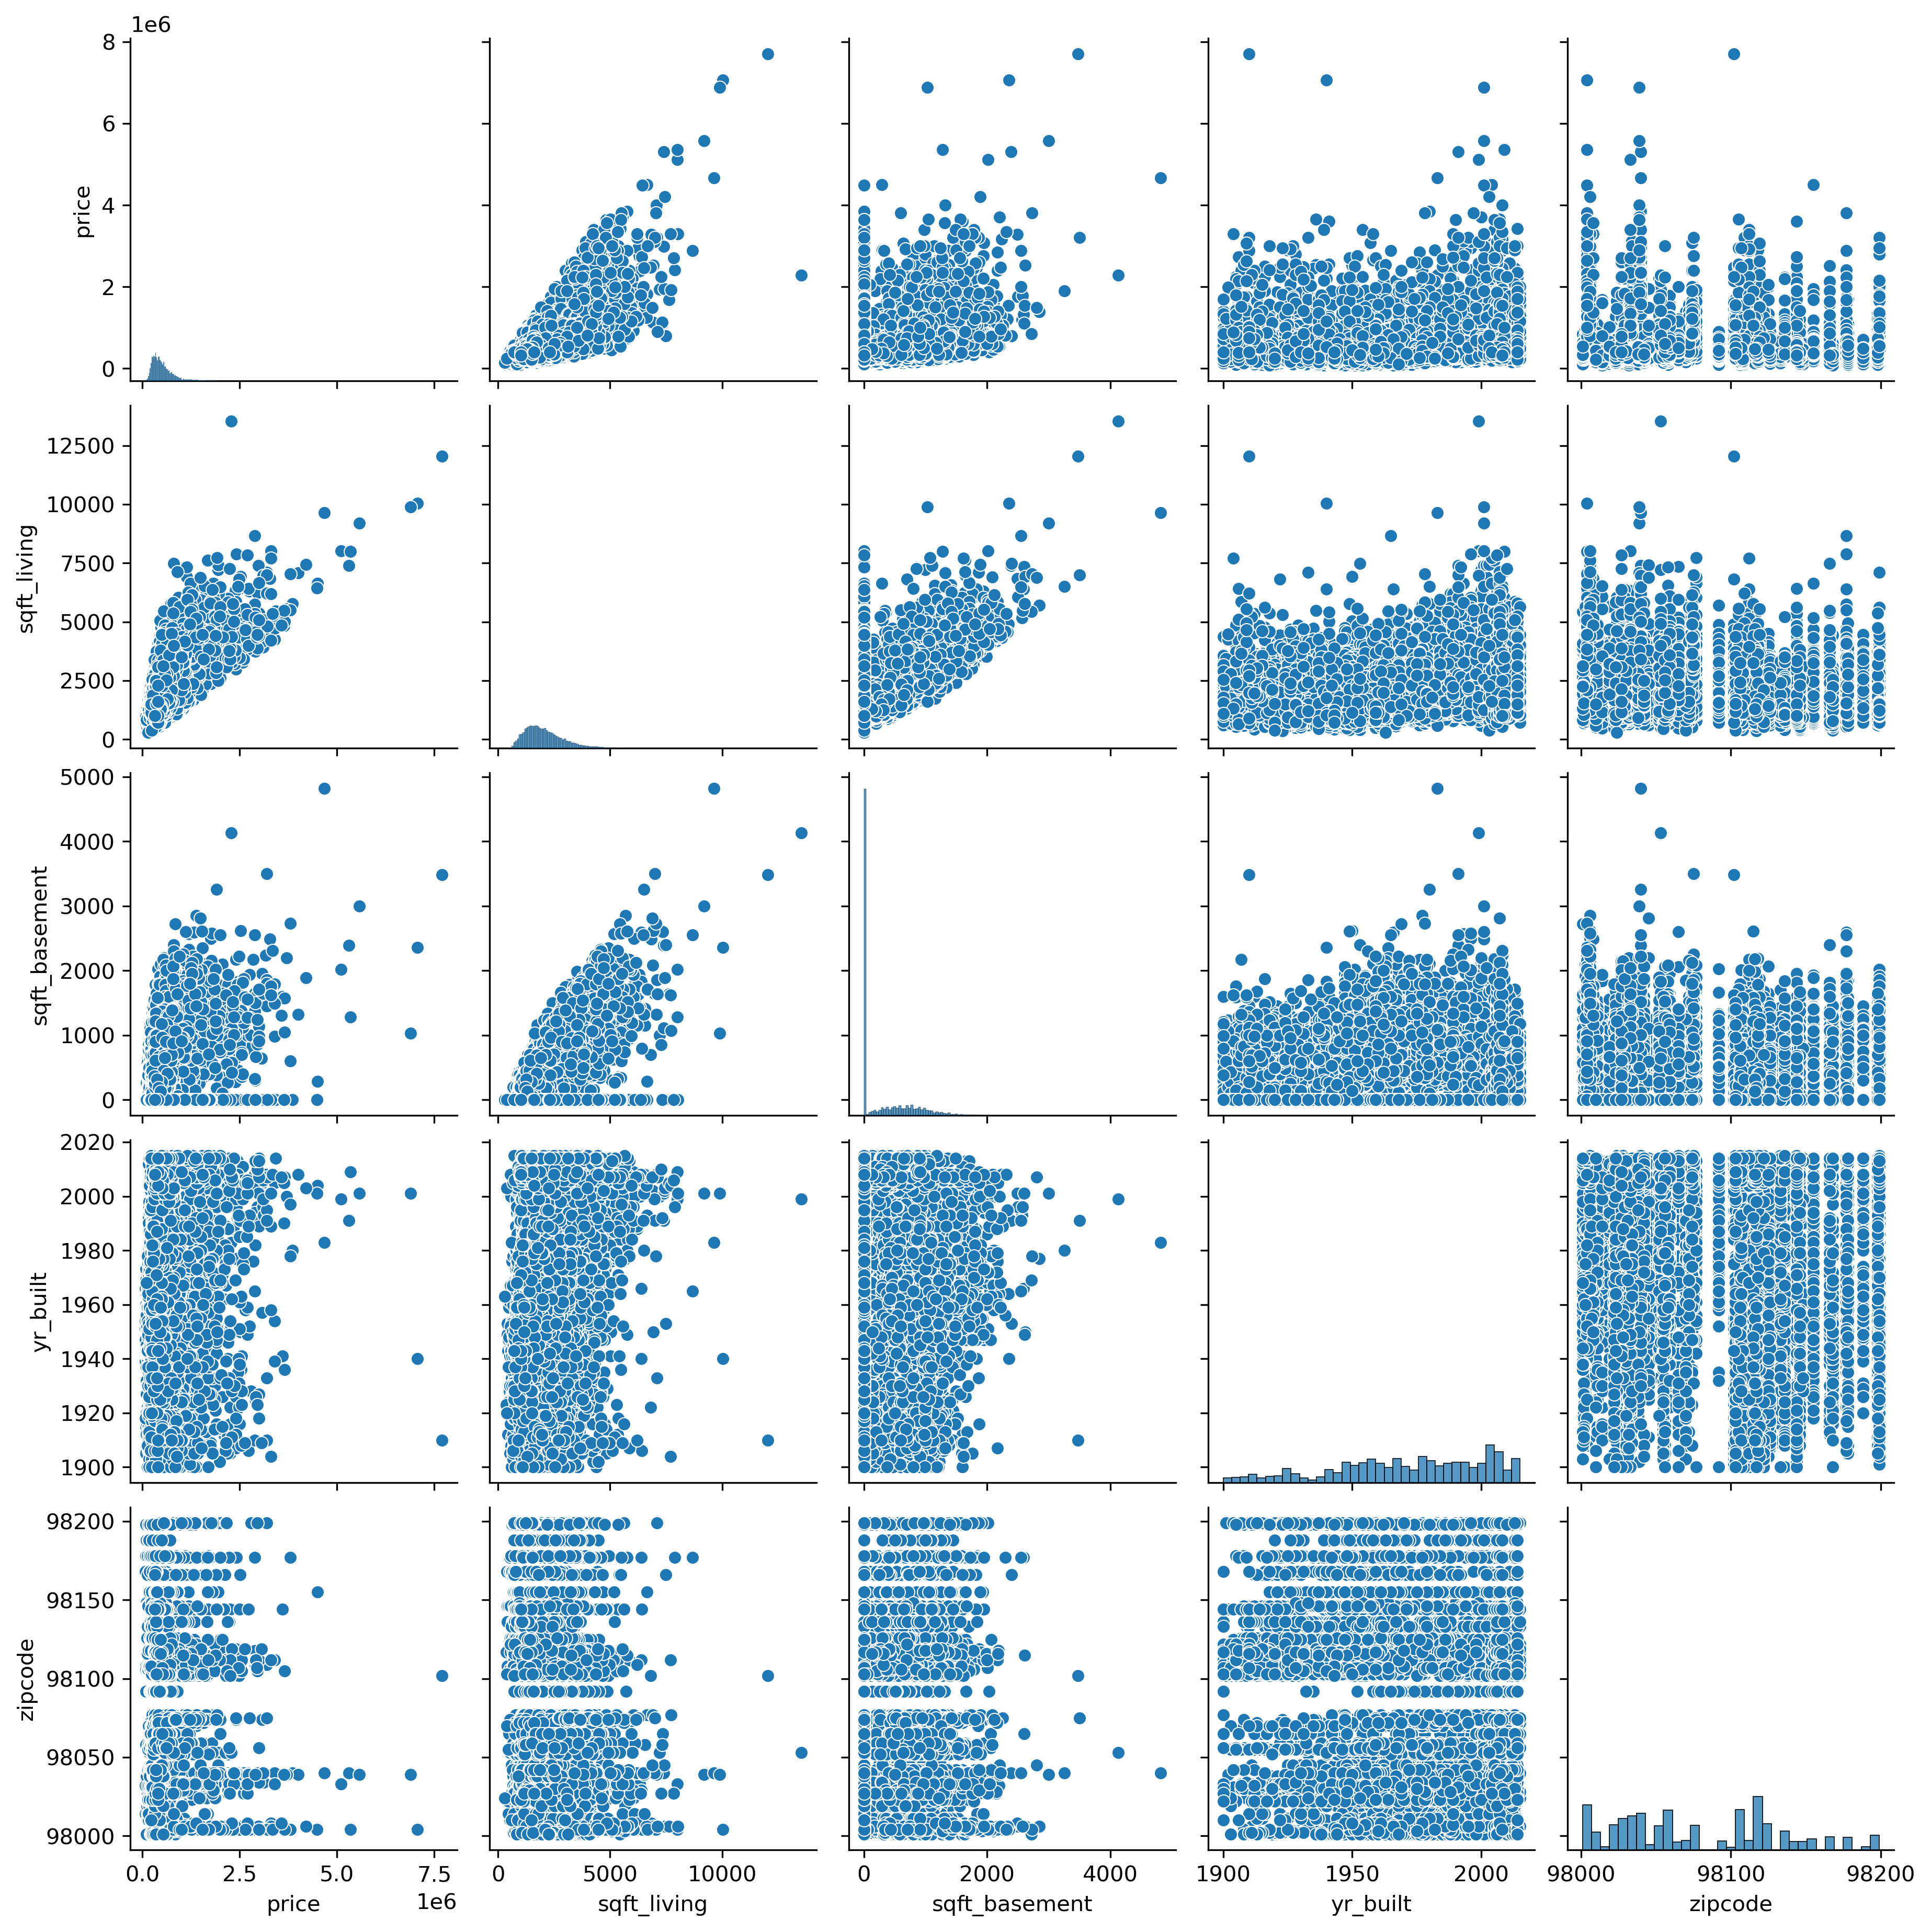

In [5]:
# 데이터 시각화 하여 분포 확인하기

import matplotlib.pyplot as plt
# matplotlib 패키지의 pyplot 모듈을 불러옴 → 데이터 시각화를 위한 기본 그래프 함수 제공 역할 수행
# seaborn, pandas 등과 함께 사용되어 시각적 해석과 인사이트 도출을 지원하는 인터페이스 제공 목적 수행

plt.rcParams['figure.dpi'] = 300
# 시각화 결과물의 해상도를 설정함 → DPI(Dots Per Inch)를 300으로 설정하여 고해상도 이미지 생성
# 보고서, 논문 등 정제된 출력물을 만들기 위한 시각적 품질 개선 목적 수행

sns.pairplot(df[["price", "sqft_living", "sqft_basement", "yr_built", "zipcode"]])
# 지정된 여러 변수 쌍 간의 산점도 행렬(Scatterplot Matrix)을 시각화함
# 각 변수 간 상관관계, 분포 특성, 이상치 패턴 등을 시각적으로 탐색하기 위한 다변량 분석 도구 역할 수행
# 대각선에는 각 변수의 히스토그램(또는 커널 밀도 함수), 비대각선에는 변수 간 관계를 나타내는 산점도를 포함함

# sns.pairplot()은 숫자형(Numeric) 데이터에 대해서만 시각화가 가능
# pairplot()에 문자열(string) 타입이나 범주형(categorical) 변수가 포함되면 에러가 발생하거나 자동으로 제외
# 예외적으로 hue 인자로는 범주형 변수를 사용할 수 있음
    # sns.pairplot(df, hue="species")  # species는 범주형이지만 그룹 구분용으로 사용됨

plt.show()
# 현재까지 작성된 모든 그래프를 화면에 출력함
# 시각화 결과를 인터프리터 또는 노트북 환경에서 확인할 수 있도록 하는 렌더링 실행 명령 수행


In [6]:
# 변수 선택 및 컬럼명 붙여넣기 위한 컬럼 리스트 생성
df.columns
# 데이터프레임의 열 이름들(컬럼명)을 출력함
# 모든 변수명을 리스트 형태로 반환하여, 변수 선택, 시각화, 전처리 작업에서 활용하기 위한 사전 정보 제공 역할 수행
# 특정 변수만 선택하거나, 분석 대상 변수를 추려낼 때 기준으로 사용되는 메타 정보 확인 절차 수행


Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [7]:
# 독립변수와 종속변수 분리하여 생성
x = df[[ 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']]
# 예측에 사용될 독립변수(입력 변수)들을 선택하여 'x' 변수에 저장함
# 주택의 물리적 특성과 위치 정보 등 가격에 영향을 줄 수 있는 피처들을 다수 포함함
# 'id', 'date' 등은 고유 식별자 또는 날짜 정보로서 수치 예측에 직접적인 영향을 주지 않으므로 제외함
# 머신러닝 모델이 학습할 입력 벡터 구성을 위해 피처셋을 정의하는 단계 수행

y = df[['price']]
# 종속변수(목표 변수)로 주택 가격을 'y' 변수로 설정함
# 회귀 모델이 학습을 통해 예측하고자 하는 목적 값(target value)을 정의함
# 예측의 정확도를 평가할 기준으로 사용되는 실제 관측값을 저장함

# 학습셋과 테스트셋 분리하여 생성(7:3)
# df_train, df_test = train_test_split(df, test_size = 0.3) 
# 전체 데이터프레임을 train/test로 분할하는 예시 코드이며, 사용되지 않음

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3)
# 전체 데이터를 학습용 데이터셋과 테스트용 데이터셋으로 7:3 비율로 분할함
# 모델 학습에는 x_train, y_train을 사용하고, 성능 평가는 x_test, y_test를 통해 수행함
# 데이터 분할은 과적합 방지와 모델의 일반화 능력을 검증하기 위한 핵심 절차로 수행됨


In [8]:
# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(x_train))
print('test data 개수: ', len(x_test))

train data 개수:  15129
test data 개수:  6484


In [10]:
# 다중회귀모델 생성
mreg = LinearRegression(fit_intercept=True)
# scikit-learn의 LinearRegression 클래스를 사용하여 다중 선형 회귀 모델 객체를 생성함
# 'fit_intercept=True' 설정은 회귀식에 절편(intercept)을 포함하겠다는 의미로, 입력 변수 외 상수항을 포함한 모델 구조를 생성함
# 입력 피처들이 0일 때의 기본값(기준선)을 예측에 반영할 수 있도록 하는 설정 역할 수행
# 회귀모델은 변수 간의 선형 관계를 가정하여 종속변수를 예측하기 위한 수학적 함수 구조 정의 목적 수행

mreg.fit(x_train, y_train)
# 학습 데이터(x_train, y_train)를 사용하여 회귀 모델을 학습함
# 독립변수(x_train)와 종속변수(y_train) 간의 선형 관계를 추정하고, 그 관계를 설명하는 회귀 계수를 계산함
# 이 과정에서 최소제곱법(Ordinary Least Squares)을 기반으로 각 독립변수에 대한 계수를 최적화함
# 학습이 완료되면 회귀식의 계수(coefficient)와 절편(intercept)이 모델 내부에 저장됨

LinearRegression()

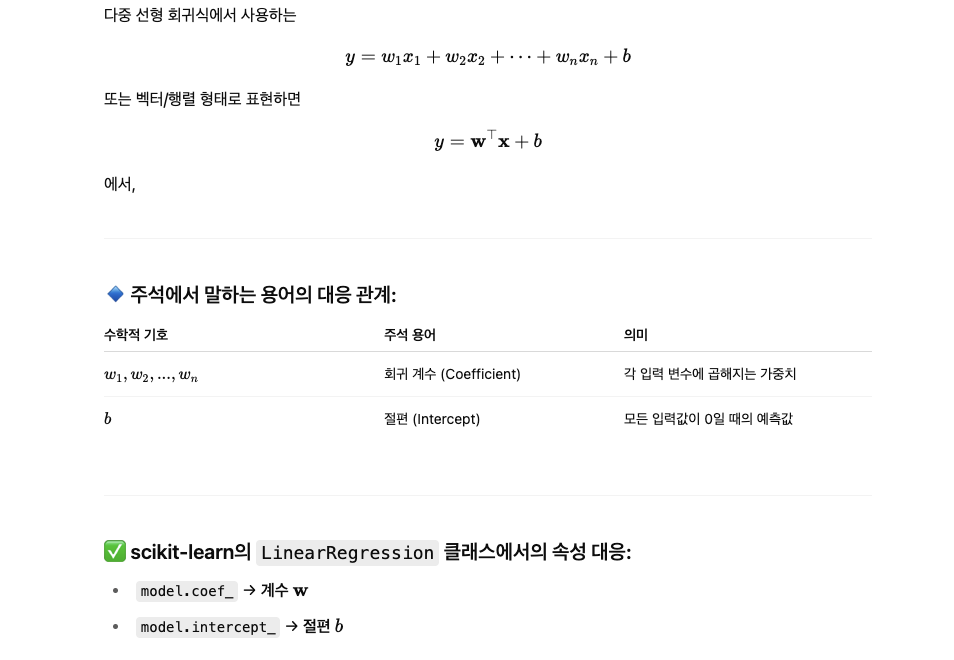

---

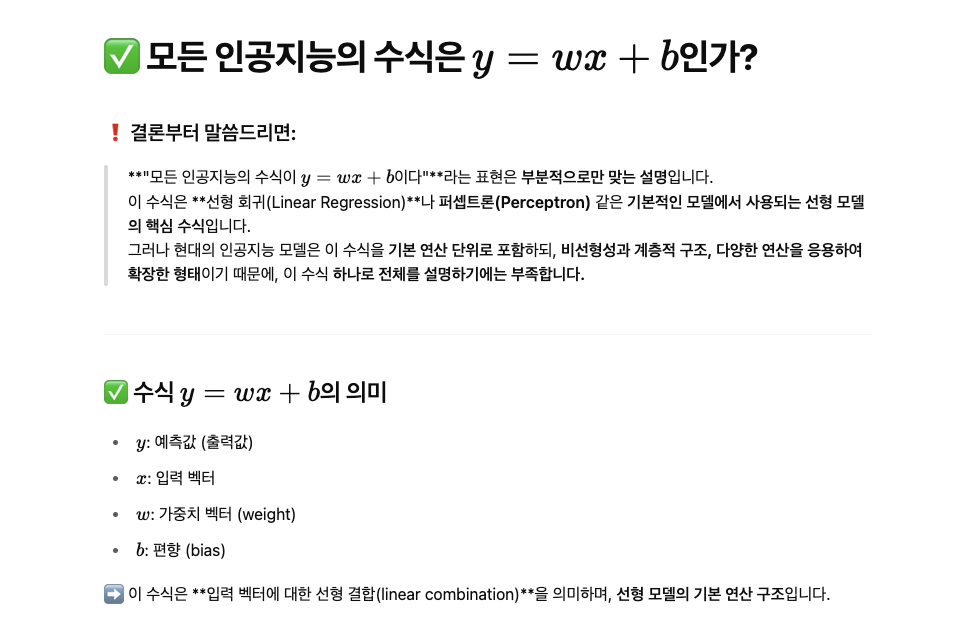

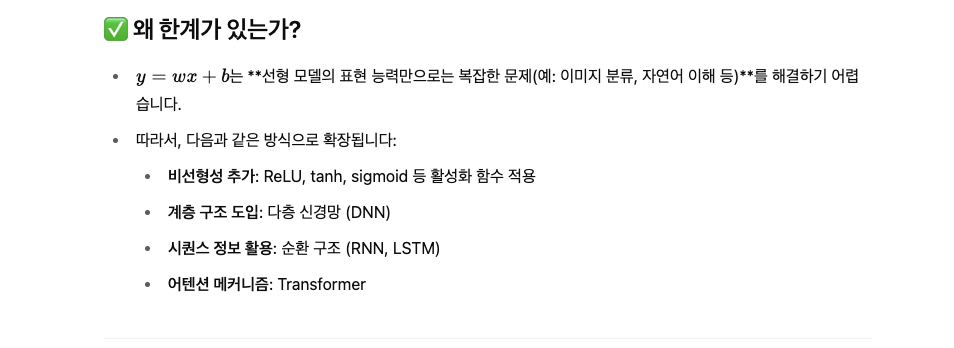

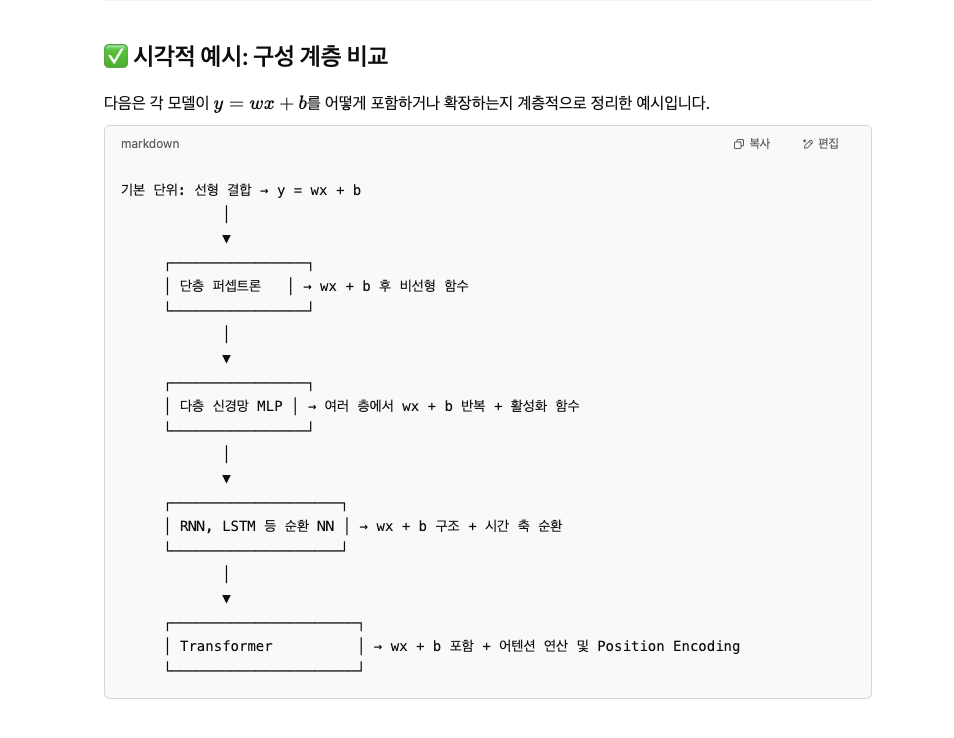

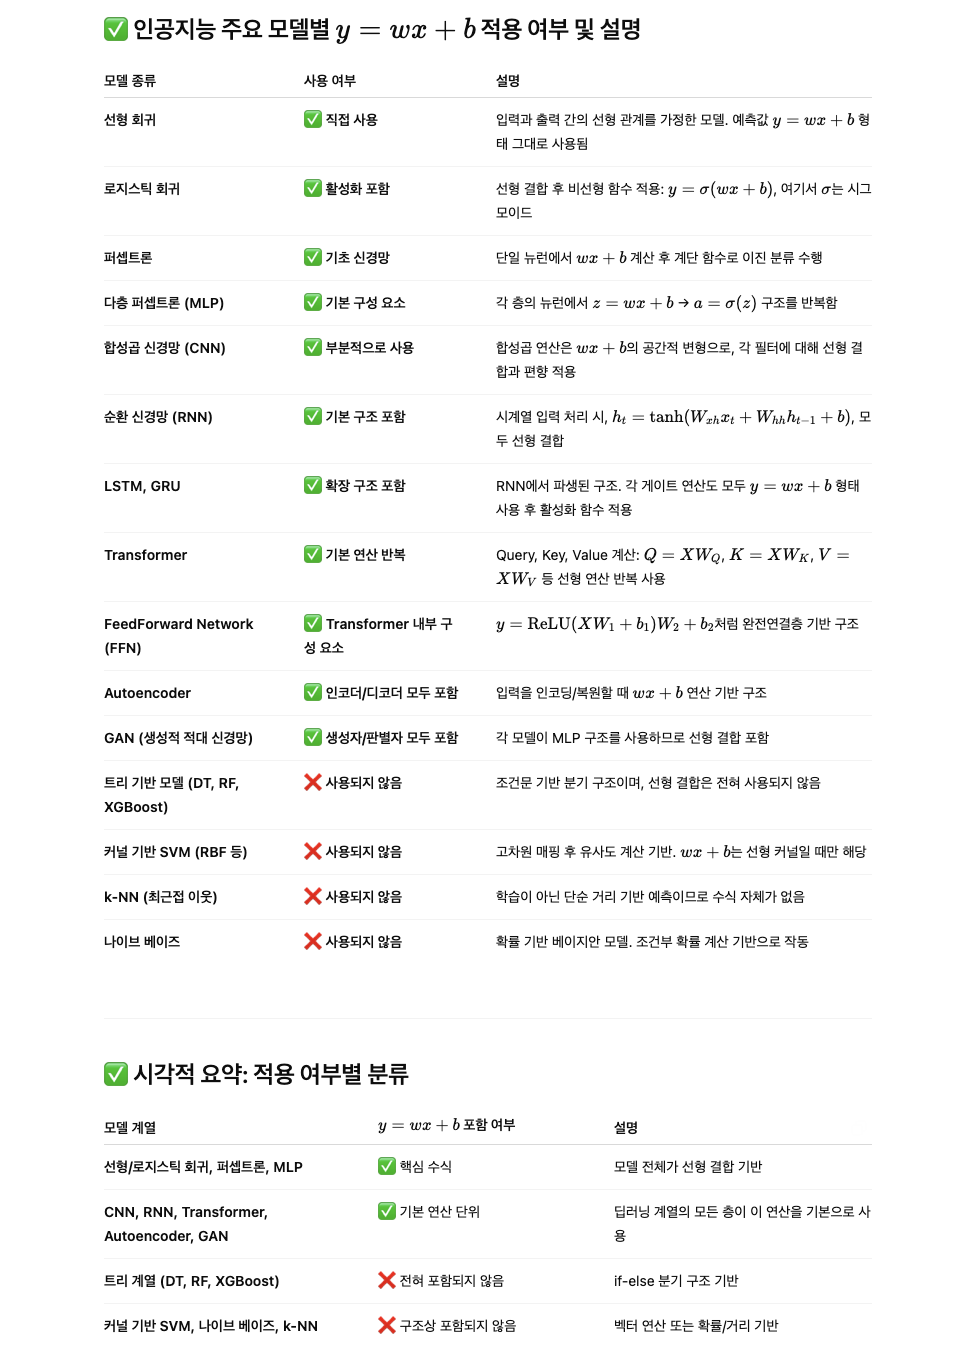

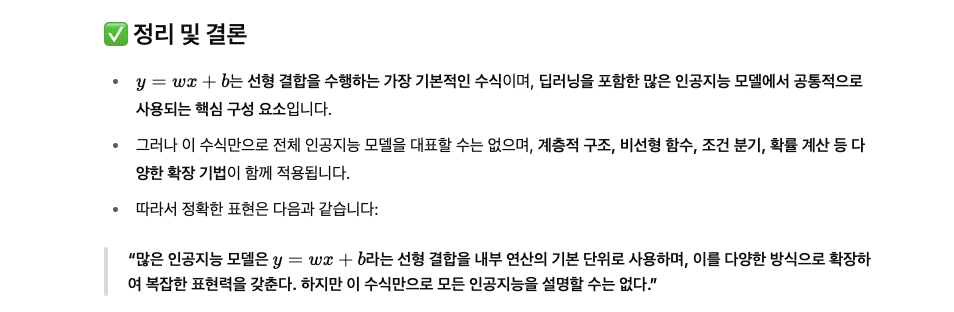

---

In [ ]:
# 테스트셋에 모델 적용
y_predict = mreg.predict(x_test)
# 학습된 선형 회귀 모델을 테스트 데이터(x_test)에 적용하여 주택 가격을 예측함
# 훈련 과정에서 계산된 회귀 계수와 절편을 이용하여, 각 테스트 샘플에 대한 종속 변수(가격) 값을 계산함
# 예측 결과는 y_test와 비교되어 모델의 일반화 성능 평가에 활용됨
# 모델이 훈련 데이터에 과적합되었는지, 실제 데이터에서 잘 작동하는지를 검증하는 실전 적용 단계 수행

In [ ]:
print("학습셋 R-Square: {:.2f}".format(mreg.score(x_train, y_train)))
# 학습 데이터셋에 대한 결정계수(R²)를 계산하여 출력함
# 결정계수는 실제 종속변수 값의 분산 중에서 회귀모델이 설명할 수 있는 비율을 나타내는 지표임
# 1에 가까울수록 모델이 데이터를 잘 설명한다는 의미이며, 0에 가까우면 설명력이 떨어짐
# 학습셋 기준의 결정계수는 모델이 훈련 데이터에 얼마나 잘 적합했는지를 판단하는 지표 역할 수행

print("테스트셋 R-Square: {:.2f}".format(mreg.score(x_test, y_test)))
# 테스트 데이터셋에 대한 결정계수(R²)를 계산하여 출력함
# 모델이 보지 않은 데이터에서도 얼마나 일반화된 성능을 가지는지를 평가함
# 학습셋과 테스트셋의 R² 값 차이를 비교하여 과적합(overfitting) 여부를 진단하는 역할 수행
# 테스트셋 기준의 R²는 실제 예측력을 수치적으로 판단하는 모델 평가 지표로 활용됨


학습셋 R-Square: 0.70
테스트셋 R-Square: 0.70


| R² 값 | 해석 |
| --- | --- |
| 1.00 | 완벽하게 설명함 (거의 없음, 과적합 가능성 존재) |
| 0.90 이상 | 매우 높은 설명력 |
| 0.70~0.90 | 실용적인 예측 가능 수준 |
| 0.50~0.70 | 일부 설명 가능하나 불완전 |
| 0.50 이하 | 설명력 낮음 → 변수 추가, 모델 변경 고려 필요 |

In [ ]:
# 모델의 상수값(절편 B) 확인
print(mreg.intercept_)
# 학습된 선형 회귀 모델의 절편(intercept) 값을 출력함
# 모든 독립변수의 값이 0일 때, 종속변수의 예측값에 해당하는 기준값을 의미함
# 회귀식의 시작점을 나타내며, 모델이 입력값 없이도 예측하는 기본 수준(base level)을 정의함

# 모델의 회귀계수(가중치 W) 확인
print(mreg.coef_)
# 각 독립변수에 대응하는 회귀 계수(coefficient) 값을 출력함
# 각 피처가 종속변수(가격)에 미치는 영향을 수치적으로 나타내며, 계수의 부호는 영향의 방향을 의미함
# 계수의 절댓값이 클수록 종속변수에 대한 영향력이 크다는 것을 의미함
# 회귀 분석의 해석력을 확보하기 위한 주요 결과 지표로 활용됨

# 그런데 LinearRegression 패키지는 R스퀘어 등 자세한 모델 결과치 확인이 어렵다. 수식을 코딩해주면 가능하지만, 여간 번거로운 일이 아니다. 
# 그래서 자세한 모델 결과값을 확인하고 싶을 때는 OLS(Ordinary Least Squares) 패키지를 사용하면 편리하다.

    # sklearn의 LinearRegression은 기본적인 회귀 모델링과 예측에는 적합하지만, 회귀 계수의 통계적 유의성, 신뢰구간, F-검정 등은 제공하지 않음
    # 통계적 해석이 필요한 경우 statsmodels의 OLS를 사용하면 각 계수에 대한 p-value, t-통계량, R², AIC, BIC 등 상세한 회귀 분석 결과를 확인할 수 있음
    # 이는 연구 목적의 해석 중심 회귀 분석 또는 회귀 진단이 필요한 상황에 적합한 접근 방식임


[7072114.1297825]
[[-3.29750920e+04  4.50881793e+04  1.06576999e+02  1.14905451e-01
   5.50353877e+03  6.05281240e+05  5.46770152e+04  2.64629188e+04
   9.35062462e+04  7.19844550e+01  3.45925441e+01 -2.62983761e+03
   1.99630502e+01 -6.00531421e+02  6.16512641e+05 -2.20981793e+05
   2.37208199e+01 -3.51311481e-01]]


In [ ]:
ols_m = sm.OLS(y_train, sm.add_constant(x_train)).fit()
# statsmodels의 OLS(Ordinary Least Squares) 클래스를 사용하여 선형 회귀 모델을 정의하고 학습함
# x_train에 대해 sm.add_constant()를 적용하여 상수항(절편)을 추가함 → 기본적으로 statsmodels는 절편을 자동으로 포함하지 않기 때문에 명시적으로 추가 필요
# y_train은 종속변수(목표값), x_train은 독립변수(예측 피처셋)에 해당하며, 최소제곱법 기반으로 회귀 계수를 추정함
# .fit() 메서드를 통해 모델을 실제로 학습시키고, 통계적 분석이 가능한 결과 객체(RegressionResultsWrapper)를 반환함
# 학습된 모델 객체는 회귀 계수, 유의성 검정 결과, 결정계수(R²), F-검정, 분산분석표 등 다양한 진단 지표를 내장함

ols_m.summary()
# 학습된 OLS 회귀 모델의 전체 통계 요약표를 출력함
# 각 변수의 회귀 계수(coef), 표준 오차(std err), t-값(t), p-값(P>|t|), 신뢰 구간(conf. int)을 포함한 표를 제공함
# 모델 전체의 결정계수(R-squared), 조정 결정계수(Adj. R-squared), F-통계량 및 p-값, AIC, BIC 등 다양한 회귀 진단 지표를 확인 가능함
# 통계적 유의성을 기반으로 변수 선택, 다중공선성 진단, 과적합 여부 평가 등 회귀 모델에 대한 정성적 해석을 지원함
# 일반적인 머신러닝 라이브러리에서는 제공하지 않는 통계 기반 해석 기능을 제공하는 분석 중심 도구로 활용됨


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     2077.
Date:                Wed, 07 May 2025   Prob (F-statistic):               0.00
Time:                        11:23:56   Log-Likelihood:            -2.0618e+05
No. Observations:               15129   AIC:                         4.124e+05
Df Residuals:                   15111   BIC:                         4.125e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7.072e+06   3.52e+06      2.011      0.044     1.8e+05     1.4e+07
bedrooms      -3.298e+04   2232.700    -14.769      0.000   -3.74e+04   -2.86e+04
bathrooms      4.509e+04   3850.430     11.710      0.000    3.75e+04    5.26e+04
sqft_living     106.5792      2.679     39.789      0.000     101.329     111.830
sqft_lot          0.1149      0.060      1.904      0.057      -0.003       0.233
floors         5503.5388   4299.157      1.280      0.201   -2923.329    1.39e+04
waterfront     6.053e+05   2.22e+04     27.292      0.000    5.62e+05    6.49e+05
view           5.468e+04   2566.749     21.302      0.000    4.96e+04    5.97e+04
condition      2.646e+04   2808.415      9.423      0.000     2.1e+04     3.2e+04
grade          9.351e+04   2571.537     36.362      0.000    8.85e+04    9.85e+04
sqft_above       71.9822      2.663     27.027      0.000      66.762      77.203
sqft_basement    34.5903      3.141     11.011      0.000      28.433      40.748
yr_built      -2629.8376     86.684    -30.338      0.000   -2799.749   -2459.926
yr_renovated     19.9631      4.342      4.597      0.000      11.452      28.474
zipcode        -600.5314     39.532    -15.191      0.000    -678.019    -523.044
lat            6.165e+05   1.28e+04     48.102      0.000    5.91e+05    6.42e+05
long           -2.21e+05   1.57e+04    -14.045      0.000   -2.52e+05    -1.9e+05
sqft_living15    23.7208      4.069      5.830      0.000      15.745      31.697
sqft_lot15       -0.3513      0.085     -4.157      0.000      -0.517      -0.186
==============================================================================
Omnibus:                    12990.351   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1414587.809
Skew:                           3.593   Prob(JB):                         0.00
Kurtosis:                      49.823   Cond. No.                     8.85e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.96e-20. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

| 항목                     | 의미                     |      |                               |
| ---------------------- | ---------------------- | ---- | ----------------------------- |
| **coef**               | 회귀 계수 (기울기)            |      |                               |
| **std err**            | 표준 오차 (계수의 신뢰도 측정)     |      |                               |
| **t**                  | t-통계량 (계수 유의성 검정)      |      |                               |
| \*\*P>                 | t                      | \*\* | p-value (0.05 미만이면 통계적으로 유의함) |
| **\[0.025, 0.975]**    | 계수의 95% 신뢰구간           |      |                               |
| **R-squared**          | 결정계수, 설명력              |      |                               |
| **Adj. R-squared**     | 조정된 결정계수 (변수 수 보정 반영)  |      |                               |
| **F-statistic**        | 전체 모델의 유의성 검정 통계량      |      |                               |
| **Prob (F-statistic)** | F 검정의 p-value          |      |                               |
| **AIC / BIC**          | 모델 비교용 정보 기준 (작을수록 좋음) |      |                               |


In [16]:
# 다항회귀 불러오기
from sklearn.preprocessing import PolynomialFeatures
# scikit-learn의 전처리 모듈에서 PolynomialFeatures 클래스를 불러옴
# 기존의 선형 독립변수들로부터 고차항(제곱, 곱 등)을 생성하여 비선형 관계를 표현할 수 있도록 확장하는 도구 역할 수행

# 다항 변수 변환
poly_m = PolynomialFeatures(degree=2, include_bias=False)
# 이 코드는 다음과 같은 작업을 준비:
# degree=2: 2차 다항식까지 생성하겠다는 의미
# → 각 변수에 대해 x, x², 그리고 변수 간 곱(x1 * x2)까지 자동으로 만듦
# include_bias=False: 상수항은 포함하지 않음
# → 절편은 LinearRegression 쪽에서 별도로 넣겠다는 의미
# 비선형 패턴을 선형 회귀 모델로 학습할 수 있도록 입력 특성 공간을 확장하는 전처리 객체 생성 역할 수행

x_train_poly = poly_m.fit_transform(x_train)
# 학습용 입력 데이터(x_train)에 대해 다항항으로 확장된 새로운 특성 행렬을 생성함
# 원래의 변수 개수보다 훨씬 많은 차원의 특징들을 포함하게 되어, 모델이 비선형성을 포착할 수 있도록 변환함
# fit_transform()은 다항항 구조를 학습(fit)한 뒤, 실제 데이터를 변환(transform)하는 통합 절차 수행

# 다항 회귀모델 생성
mreg_poly = LinearRegression(fit_intercept=True)
# 다항항을 포함한 데이터를 학습할 선형 회귀 모델 객체를 생성함
# fit_intercept=True는 회귀식에 y절편(상수항)을 포함시킨다는 설정임
# PolynomialFeatures로 확장된 다항 피처는 여전히 선형 회귀 방식으로 처리되며, 이는 선형모델 기반의 비선형 회귀 접근 방식임

# 다항회귀 학습
mreg_poly.fit(x_train_poly, y_train)
# 변환된 학습 데이터(x_train_poly)를 기반으로 다항 회귀 모델을 학습시킴
# 고차항 및 교차항을 포함한 독립변수들에 대해 최적의 회귀 계수를 추정함
# 복잡한 비선형 관계를 모형에 반영함으로써 예측 정확도를 높이기 위한 확장된 모델 학습 단계 수행

# 테스트셋에 모델 적용
x_test_poly = poly_m.fit_transform(x_test)
# 테스트 입력 데이터(x_test)에 대해 동일한 방식의 다항 변환을 적용함
# 주의: 일반적으로는 학습 데이터 기준으로 학습된 poly_m 객체를 사용해 `transform()`만 수행하는 것이 바람직함 (여기선 fit_transform 사용됨)
    # 이유는:
    #     fit_transform()은 새롭게 피처 구성을 학습하기 때문에 훈련셋 기준의 다항 구조와 달라질 수 있음
    #     일관된 피처 구조 보장을 위해, 테스트셋에는 반드시 fit된 객체로 transform()만 사용해야 함
    # 수정 권장 코드:
    #     x_test_poly = poly_m.transform(x_test)

y_predict_poly = mreg_poly.predict(x_test_poly)
# 다항 회귀 모델을 테스트셋에 적용하여 예측값을 생성함
# 확장된 피처 공간을 기반으로 비선형 관계를 반영한 예측 결과 도출 단계 수행


| 개념 | 쉬운 설명 |
| --- | --- |
| **다항회귀란?** | 선형회귀에 변수의 제곱, 곱 같은 고차항을 추가해서 더 복잡한 곡선 형태의 예측을 가능하게 하는 기법 |
| **PolynomialFeatures** | 기존 변수들을 바탕으로 `x²`, `x*y` 같은 새로운 변수를 자동 생성해주는 도구 |

In [17]:
# 모델의 상수값 확인
print(mreg_poly.intercept_)
# 회귀식에서 상수항(절편, intercept)의 값을 출력함
# 상수항이란, 모든 독립변수가 0일 때 예측되는 종속변수의 기본값을 의미함
# 예: y = a₀ + a₁x₁ + a₂x₂ + ... 에서 a₀에 해당하는 값이며, 예측의 기준점 역할을 수행함

# 모델의 회귀계수 확인
print(mreg_poly.coef_)
# 각 독립변수(다항항 포함)에 해당하는 회귀계수(coefficient) 값을 출력함
# 회귀계수란, 각 변수(또는 변수의 곱, 제곱)가 종속변수에 얼마나 영향을 주는지를 나타내는 값임
# 예를 들어, coef_ 중 하나가 500이면 해당 변수 값이 1 증가할 때 종속변수(y)는 평균적으로 500만큼 증가한다는 의미임
# 다항 회귀에서는 x, x², x1*x2 등 다양한 조합의 변수들이 포함되므로 계수의 개수가 매우 많아질 수 있음
# 이 계수들을 해석하면 어떤 변수(또는 변수의 조합)가 예측에 크게 기여하는지 파악할 수 있음


[-35705243.38527661]
[[-1.94421133e+01  9.01747187e+00 -1.71615302e+03 -3.82676818e+02
   1.06218475e+01  1.69310388e+00  2.16498240e+01 -1.01045247e+01
   1.45494723e+01  1.20343094e+04 -1.37504263e+04 -1.21143085e+02
   3.69325514e+04  1.96378545e+02 -4.53536039e+00 -2.20136637e-01
   1.70500137e+04  1.17290212e+03  7.17572054e+02 -1.57621751e+03
  -1.46098114e+01  2.54545289e-01  1.25832956e+04  9.52535747e+02
   4.82989425e+03 -2.28283188e+03  7.11800398e+02 -2.05746852e+00
  -1.25527998e+01 -2.72905032e+02 -9.06978710e+00  2.10988784e+01
  -5.22448753e+04 -7.73655778e+03  1.12102273e+01 -1.20114750e-01
  -5.98942927e+03  2.34593809e+01 -5.29101633e-01 -2.72478526e+04
   2.78522787e+02  1.12534724e+04 -7.52170155e+03  1.78316100e+04
   2.14652279e+01  1.99415639e+00  2.70859906e+02 -1.42398581e+01
  -3.26489456e+00 -7.95918598e+03 -8.13179157e+02 -1.86489783e+01
   3.42499580e-01 -2.83813202e-03 -9.70032941e-04 -5.80838263e+00
   9.04141399e+01 -1.25365900e+01  1.17808859e+01  1.74

In [18]:
print("학습셋 R-Square: {:.2f}".format(mreg_poly.score(x_train_poly, y_train)))
# 학습 데이터에 대해 다항 회귀 모델의 R²(결정계수)를 계산하고 소수점 둘째 자리까지 출력함
# 결정계수는 모델이 실제 데이터를 얼마나 잘 설명하는지를 나타내는 지표임
# R² 값은 0에서 1 사이의 값을 가지며, 1에 가까울수록 예측력이 높음을 의미함
# 학습 데이터 기준의 R²는 모델이 훈련 데이터에 얼마나 잘 맞는지를 보여주며, 과적합 여부 판단의 기준이 됨

print("테스트셋 R-Square: {:.2f}".format(mreg_poly.score(x_test_poly, y_test)))
# 테스트 데이터에 대해 다항 회귀 모델의 R² 값을 계산하고 출력함
# 이 값은 모델이 처음 보는 데이터에 대해 얼마나 잘 일반화되었는지를 판단하는 기준임
# 학습셋 R²와 테스트셋 R²의 차이가 크면 모델이 과적합(overfitting)된 것일 수 있음
# 일반적으로 테스트셋 R²가 일정 수준 이상 유지되면 예측 모델로서의 유효성을 인정할 수 있음


학습셋 R-Square: 0.81
테스트셋 R-Square: 0.79


In [ ]:
# Ridge 설치

from sklearn.linear_model import Ridge
# 선형 회귀에 정규화(규제)를 적용한 Ridge 회귀 모델을 불러옴
# Ridge 회귀는 과적합(overfitting)을 줄이기 위해 계수 크기에 패널티를 부여하는 방식임
# L2 정규화를 기반으로 하며, 큰 회귀 계수를 억제해 모델의 복잡도를 조절함

# alpha 별 모델 생성

ridge = Ridge().fit(x_train, y_train)
# 기본 alpha=1.0 설정으로 Ridge 모델 학습 수행
# alpha는 정규화 강도를 조절하는 하이퍼파라미터이며, 값이 클수록 규제가 강해짐
# fit()은 입력 데이터를 기반으로 회귀 계수를 학습하는 과정 수행

ridge001 = Ridge(alpha=0.01).fit(x_train, y_train)
# alpha=0.01로 설정하여 정규화를 거의 하지 않는 모델 생성
# 선형회귀와 유사한 성질을 가지며, 계수 크기에 거의 제약이 없음

ridge100 = Ridge(alpha=100).fit(x_train, y_train)
# alpha=100으로 설정하여 강한 정규화 효과를 적용한 모델 생성
# 과적합 방지 효과는 크지만, 예측력이 낮아질 수 있음 (과소적합 가능성 존재)

# 모델 별 R-Square 산출

print("ridge_train R2: {:.3f}".format(ridge.score(x_train, y_train)))
# 기본 alpha=1.0 설정으로 학습된 Ridge 모델의 학습셋 R² 출력
# R²는 모델이 종속변수(y)를 얼마나 잘 설명하는지를 수치적으로 보여주는 지표임
print("ridge_test R2: {:.3f}".format(ridge.score(x_test, y_test)))
# 동일한 모델의 테스트셋 R² 출력
# 테스트셋 R²는 일반화 성능을 판단하는 핵심 기준임

print("ridge001_train R2: {:.3f}".format(ridge001.score(x_train, y_train)))
# alpha=0.01인 모델의 학습셋 R² 출력
# 정규화가 거의 없으므로 학습셋에 매우 잘 맞지만, 테스트셋 성능이 나쁠 수 있음 → 과적합 가능성 존재
print("ridge001_test R2: {:.3f}".format(ridge001.score(x_test, y_test)))
# alpha=0.01 모델의 테스트셋 R² 출력
# 일반화 성능이 낮다면 과적합으로 해석할 수 있음

print("ridge100_train R2: {:.3f}".format(ridge100.score(x_train, y_train)))
# alpha=100인 모델의 학습셋 R² 출력
# 계수를 강하게 제약하여 학습셋 적합도가 낮아지는 현상이 발생함 → 과소적합 가능성 존재
print("ridge100_test R2: {:.3f}".format(ridge100.score(x_test, y_test)))
# alpha=100 모델의 테스트셋 R² 출력
# 적절한 일반화 성능이 나타나는지 확인하는 단계임


ridge_train R2: 0.700
ridge_test R2: 0.698
ridge001_train R2: 0.700
ridge001_test R2: 0.698
ridge100_train R2: 0.691
ridge100_test R2: 0.691


### Ridge 회귀의 핵심 포인트

| 개념 | 설명 |
| --- | --- |
| **Ridge 회귀** | 과적합을 방지하기 위해 계수의 크기를 제어하는 선형 회귀 방법 (L2 정규화) |
| **alpha (λ)** | 정규화 강도 조절 → 클수록 계수에 강한 제약, 작을수록 선형회귀에 가까워짐 |
| **alpha 선택** | 너무 작으면 과적합, 너무 크면 과소적합 → 적절한 값 찾기 위해 검증 필요 |

In [21]:
# Lasso 설치
from sklearn.linear_model import Lasso
# scikit-learn의 Lasso 회귀 모델 불러오기
# Lasso는 회귀 계수 중 중요하지 않은 변수의 계수를 '0'으로 만들어 자동으로 변수 선택을 수행함
# L1 정규화를 기반으로 하며, 불필요한 변수를 제거하여 모델을 더 간결하고 해석 가능하게 만드는 효과를 가짐

# alpha 별 모델 생성

lasso = Lasso().fit(x_train, y_train)
# 기본 alpha=1.0으로 설정된 Lasso 모델 학습 수행
# fit()은 입력된 학습 데이터를 바탕으로 회귀 계수를 계산함

lasso001 = Lasso(alpha=0.01).fit(x_train, y_train)
# alpha=0.01로 정규화 강도를 매우 약하게 설정하여 Lasso 회귀 모델 생성
# 회귀 계수에 거의 제약을 두지 않으므로 많은 변수가 살아남게 됨 → 선형회귀와 유사한 형태 유지

lasso10000 = Lasso(alpha=10000).fit(x_train, y_train)
# alpha=10000으로 매우 강한 정규화를 적용한 모델 생성
# 대부분의 회귀 계수가 0이 되므로 변수 선택이 극단적으로 이루어짐 → 모델이 거의 예측을 못할 수도 있음


# 모델 별 R-Square 산출
print("lasso_train R2: {:.3f}".format(lasso.score(x_train, y_train)))
# 기본 Lasso 모델의 학습 데이터에 대한 R² 출력
# R²는 예측값이 실제값을 얼마나 잘 설명하는지 나타내는 결정계수임
print("lasso_test R2: {:.3f}".format(lasso.score(x_test, y_test)))
# 기본 Lasso 모델의 테스트셋 R² 출력
# 일반화 성능을 평가하기 위한 지표로 사용됨
print("num_of_IV:", np.sum(lasso.coef_ !=0))
# 회귀 계수가 0이 아닌 변수의 개수를 출력함
# Lasso는 중요하지 않은 변수의 계수를 0으로 만들기 때문에 실제 모델에 사용된 변수의 수를 확인할 수 있음
# 변수 선택 효과를 수치적으로 확인하는 단계 수행

print("lasso001_train R2: {:.3f}".format(lasso001.score(x_train, y_train)))
# alpha=0.01 모델의 학습셋 R² 출력
# 정규화가 거의 없기 때문에 더 높은 R²를 가질 수 있음
print("lasso001_test R2: {:.3f}".format(lasso001.score(x_test, y_test)))
# alpha=0.01 모델의 테스트셋 R² 출력
# 과적합 여부를 판단하는 기준이 될 수 있음
print("num_of_IV:", np.sum(lasso001.coef_ !=0))
# alpha=0.01 모델에서 회귀 계수가 0이 아닌 변수의 수를 출력함
# 정규화가 약하기 때문에 대부분의 변수가 살아남을 가능성이 높음

print("lasso10000_train R2: {:.3f}".format(lasso10000.score(x_train, y_train)))
# alpha=10000 모델의 학습셋 R² 출력
# 정규화가 너무 강해 대부분의 계수가 0이 되어 학습 성능이 급격히 떨어질 수 있음 → 과소적합 가능성 존재
print("lasso10000_test R2: {:.3f}".format(lasso10000.score(x_test, y_test)))
# alpha=10000 모델의 테스트셋 R² 출력
# 성능이 낮다면 지나치게 단순한 모델이 되어 예측력이 손상된 상태일 가능성 존재
print("num_of_IV:", np.sum(lasso10000.coef_ !=0))
# alpha=10000 모델에서 살아남은 변수 개수를 출력함
# 정규화 강도가 너무 높아 거의 모든 계수가 0이 되는 현상 발생 가능



/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.798e+14, tolerance: 2.032e+11
  model = cd_fast.enet_coordinate_descent(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.798e+14, tolerance: 2.032e+11
  model = cd_fast.enet_coordinate_descent(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

lasso_train R2: 0.700
lasso_test R2: 0.698
num_of_IV: 18
lasso001_train R2: 0.700
lasso001_test R2: 0.698
num_of_IV: 18
lasso10000_train R2: 0.629
lasso10000_test R2: 0.629
num_of_IV: 14


### Lasso 회귀 핵심 포인트

| 개념 | 설명 |
| --- | --- |
| **Lasso 회귀** | L1 정규화를 이용해 불필요한 변수의 회귀 계수를 0으로 만드는 회귀 방식 |
| **alpha** | 정규화 강도를 결정하는 값 → 높을수록 많은 변수가 제거됨 |
| **변수 선택 효과** | `coef_ != 0`인 변수의 수를 세면 실제 모델이 사용한 변수 수를 알 수 있음 |



In [ ]:
# ElasticNet 설치

from sklearn.linear_model import ElasticNet
# scikit-learn의 ElasticNet 회귀 모델 불러오기
# ElasticNet은 Ridge(L2)와 Lasso(L1) 회귀의 특성을 결합한 모델임
# L1 규제로 불필요한 변수를 제거하면서, L2 규제로 계수 크기를 안정화시키는 절충형 정규화 방식임


# alpha 별 모델 생성

elast = ElasticNet().fit(x_train, y_train)
# 기본 설정(alpha=1.0, l1_ratio=0.5)으로 ElasticNet 모델 생성 및 학습 수행
# l1_ratio는 L1과 L2 규제의 혼합 비율을 나타내며, 0이면 Ridge, 1이면 Lasso에 가까워짐

elast001 = ElasticNet(alpha=100, l1_ratio=0.1).fit(x_train, y_train)
# alpha=100으로 정규화 강도를 설정하고, L1 비율을 10%로 낮춘 모델 학습
# 대부분의 규제가 L2에 집중되어 계수 축소가 주로 발생하며, 일부 변수 선택 기능은 유지됨

elast10000 = ElasticNet(alpha=10000, l1_ratio=1).fit(x_train, y_train)
# alpha=10000으로 매우 강한 정규화 설정, l1_ratio=1이므로 사실상 Lasso와 동일한 효과 발생
# 대부분의 계수가 0이 되고, 변수 수가 급격히 줄어드는 극단적인 단순 모델 형성됨


# 모델 별 R-Square 산출
print("elast_train R2: {:.3f}".format(elast.score(x_train, y_train)))
# 기본 ElasticNet 모델의 학습셋에 대한 결정계수(R²)를 계산하여 출력함
# 회귀 모델이 실제 데이터를 얼마나 잘 설명하는지 평가하는 지표임
print("elast_test R2: {:.3f}".format(elast.score(x_test, y_test)))
# 기본 ElasticNet 모델의 테스트셋에 대한 R²를 계산하여 출력함
# 일반화 성능을 수치적으로 평가하기 위한 단계임
print("num_of_IV:", np.sum(elast.coef_ != 0))
# 회귀 계수가 0이 아닌 변수의 개수를 출력함
# L1 규제의 효과로 일부 계수가 0으로 바뀌므로, 실제로 모델에 사용된 변수 개수를 확인할 수 있음

print("elast001_train R2: {:.3f}".format(elast001.score(x_train, y_train)))
# alpha=100, L1 비율 10%인 ElasticNet 모델의 학습셋 R² 출력
# 적절한 규제 수준일 경우 예측력과 해석력의 균형을 잡을 수 있음
print("elast001_test R2: {:.3f}".format(elast001.score(x_test, y_test)))
# 동일 모델의 테스트셋 R² 출력
# 과적합 방지 효과를 확인하는 일반화 성능 평가 지표로 활용됨
print("num_of_IV:", np.sum(elast001.coef_ != 0))
# 해당 모델에서 실제로 사용된 변수의 개수 출력
# 규제가 약하기 때문에 많은 변수가 선택될 수 있음

print("elast10000_train R2: {:.3f}".format(elast10000.score(x_train, y_train)))
# alpha=10000, L1 비율 100% → 매우 강한 Lasso 모델과 동일
# 회귀 계수 대부분이 0에 수렴하고 예측력이 크게 낮아질 수 있음 (과소적합 가능성 존재)
print("elast10000_test R2: {:.3f}".format(elast10000.score(x_test, y_test)))
# 테스트셋에서의 예측 성능 확인
# 모델이 지나치게 단순하여 성능이 급격히 떨어질 수 있음
print("num_of_IV:", np.sum(elast10000.coef_ != 0))
# 0이 아닌 회귀 계수의 개수 출력 → 모델에 실제 사용된 변수의 수를 나타냄
# 정규화 강도가 너무 강해 거의 모든 변수가 제거될 수 있음

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.104e+14, tolerance: 2.032e+11
  model = cd_fast.enet_coordinate_descent(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.620e+14, tolerance: 2.032e+11
  model = cd_fast.enet_coordinate_descent(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

elast_train R2: 0.620
elast_test R2: 0.617
num_of_IV: 18
elast001_train R2: 0.549
elast001_test R2: 0.537
num_of_IV: 18
elast10000_train R2: 0.629
elast10000_test R2: 0.629
num_of_IV: 14


### 📌 **Tip: 모델 선택 전략**

- Ridge: 변수 수는 그대로 두고 계수만 작게 만들고 싶을 때
- Lasso: 중요하지 않은 변수를 아예 제거하고 싶을 때
- ElasticNet: 둘의 장점을 혼합해서 사용하고 싶을 때